In [1]:
%load_ext autoreload
%autoreload 2
%cd ../..

/home/philippe/MolGenDocking


# Loading

In [2]:
from pathlib import Path
import json
import re

import pandas as pd
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import os
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import DataStructs

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import roc_curve, roc_auc_score
from notebooks.utils import PandasTableFormatter
from molrgen.evaluation.diversity_aware_top_k import diversity_aware_top_k
from notebooks.utils import *

FIG_PATH = "MolGenDocking-latex/Figures/Results/MolProp"
os.makedirs(FIG_PATH, exist_ok=True)


In [3]:
MOLSTRAL_PATH = Path("MolGenOutput/property_prediction")

files = [f for f in MOLSTRAL_PATH.iterdir()]
files = sorted(files)
print(files)
full_df = load_molprop_results(files)

[PosixPath('MolGenOutput/property_prediction/ChemDFM-R-14B'), PosixPath('MolGenOutput/property_prediction/MiniMax-M2'), PosixPath('MolGenOutput/property_prediction/Mistral-Small-4-128B'), PosixPath('MolGenOutput/property_prediction/Qwen3-30B-A3B-Thinking-2507'), PosixPath('MolGenOutput/property_prediction/Qwen3Next_thinking'), PosixPath('MolGenOutput/property_prediction/RL-Molstral-g16'), PosixPath('MolGenOutput/property_prediction/RL-Molstral-g4'), PosixPath('MolGenOutput/property_prediction/RL-Molstral-g8'), PosixPath('MolGenOutput/property_prediction/ether0'), PosixPath('MolGenOutput/property_prediction/gemma-3-27b-it'), PosixPath('MolGenOutput/property_prediction/gemma-4-31B-it')]
MolGenOutput/property_prediction/ChemDFM-R-14B/out_0_scored.jsonl
MolGenOutput/property_prediction/ChemDFM-R-14B/out_2_scored.jsonl
MolGenOutput/property_prediction/ChemDFM-R-14B/out_1_scored.jsonl
MolGenOutput/property_prediction/MiniMax-M2/out_9_scored.jsonl
MolGenOutput/property_prediction/MiniMax-M2/o

In [4]:
from tqdm import tqdm
tqdm.pandas()

full_df = full_df.groupby(["Model", "prompt_id", "Task"]).head(5)
# For each model, drop tasks where not all prompt_ids appear
# Get the set of prompt_ids per task (reference)
prompt_ids_per_task = full_df.groupby("Task").prompt_id.apply(set)
# Get the set of prompt_ids per (Model, Task)
prompt_ids_per_model_task = full_df.groupby(["Model", "Task"]).prompt_id.apply(set)
# Check which (Model, Task) combinations have all prompt_ids
valid_model_tasks = prompt_ids_per_model_task.reset_index()
valid_model_tasks["all_prompts"] = valid_model_tasks.apply(
    lambda x: x.prompt_id == prompt_ids_per_task[x.Task], axis=1
)
valid_model_tasks = valid_model_tasks[valid_model_tasks["all_prompts"]][["Model", "Task"]]
# Filter using merge (much faster than row-wise apply)
full_df = full_df.merge(valid_model_tasks, on=["Model", "Task"], how="inner")


In [5]:
df_validity_no_numeric_mistake = full_df.groupby(["Model", "prompt_id", "Task", "objectives"])[["validity", "contains_numeric"]].apply(
    lambda x: any(x.validity) or not any(x.contains_numeric)
).reset_index().rename(columns={0: "non-valid-and-numeric"})

df_validity = full_df.groupby(["Model", "prompt_id", "Task", "objectives"]).validity.apply(
    lambda x: any(x)
).reset_index()

# Merge to get contains_numeric info
df_validity = df_validity.merge(
    df_validity_no_numeric_mistake,
    on=["Model", "prompt_id", "Task", "objectives"],
    how="left"
)


df_validity = df_validity.groupby(["Model", "Task", "objectives"])[["validity", "non-valid-and-numeric"]].mean().reset_index()
df_validity

,Model,Task,objectives,validity,non-valid-and-numeric
0,ChemDFM-R,ames,classification,1.0,1.0
1,ChemDFM-R,antiviral-potency,regression,1.0,1.0
2,ChemDFM-R,az-logd,regression,1.0,1.0
3,ChemDFM-R,az-ppb-clearance,regression,1.0,1.0
4,ChemDFM-R,bbb,classification,1.0,1.0
...,...,...,...,...,...
292,gemma-4,mic-clearance-az,regression,1.0,1.0
293,gemma-4,pgp,classification,1.0,1.0
294,gemma-4,pkis2-drewry,classification,1.0,1.0
295,gemma-4,solubility,regression,1.0,1.0


In [6]:
df_validity["Model"] = df_validity["Model"].str.replace("Qwen3Next", "Qwen3-Next", regex=False)

/tmp/ipykernel_3047192/3019558861.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_3047192/3019558861.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


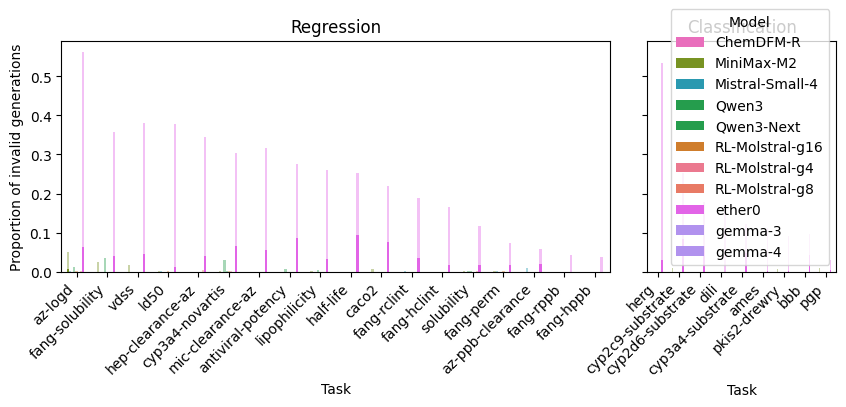

In [7]:
prop_cls = df_validity[df_validity.objectives == "classification"].Task.nunique() / df_validity.Task.nunique()/1.3

fig, axes = plt.subplots(1,2,figsize=(10,3), gridspec_kw={"wspace":0.1, "width_ratios": [1-prop_cls, prop_cls]}, sharey=True)

for obj, ax in zip(["regression", "classification"], axes):
    df_obj = df_validity[df_validity.objectives == obj]
    x_order = df_obj.groupby("Task").validity.mean().sort_values().index.tolist()
    df_obj["missed"] = 1- df_obj["validity"]
    df_obj["missed-and-numeric"] =1 - df_obj["non-valid-and-numeric"]
    kwargs = dict( data=df_obj, x="Task", hue="Model", palette=CMAP_MODELS, order=x_order, ax=ax,)
    sns.barplot(
        y="missed-and-numeric",
        legend=obj == "classification",
        alpha = 1,
        **kwargs
    )
    sns.barplot(
        y="missed",
        legend=False,
        alpha = 0.4,
        **kwargs
    )
    ax.set_title(obj.capitalize())
    _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    if ax == axes[0]:
        ax.set_ylabel("Proportion of invalid generations")
    else:
        ax.set_ylabel("")

fig.savefig(f"{FIG_PATH}/valid_.pdf", bbox_inches="tight")

# Metric Computation

## Regression

In [8]:
# Compute Spearman_corr
df = full_df[full_df.objectives == "regression"]
def get_yagg(values):
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.mean(values)

df["y_agg"] = df.groupby(["Model", "prompt_id"]).y.transform(get_yagg)

correlations = df[df.validity == 1].groupby(["Model", "Task"])[["gt", "y_agg"]].corr(method="pearson").loc[pd.IndexSlice[:, :, "gt"], "y_agg"]
correlations = correlations.reset_index(level=2, drop=True)

coverage = df.groupby(["Model", "Task"]).validity.mean()

corr_cov_score = (correlations+1) * coverage - 1
corr_cov_score.fillna(-1, inplace=True)

corr_cov_score

Model      Task             
ChemDFM-R  antiviral-potency    0.134519
           az-logd              0.340110
           az-ppb-clearance    -0.154449
           caco2                0.343890
           cyp3a4-novartis     -0.081372
                                  ...   
gemma-4    ld50                -0.197243
           lipophilicity        0.299069
           mic-clearance-az     0.047566
           solubility           0.856047
           vdss                 0.476809
Length: 198, dtype: float64

## Classification

In [9]:
df = full_df[full_df.objectives == "classification"]

def get_yagg(values):
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.round(np.mean(values) + 1e-8 * values[0]).clip(0,1)

df["y_agg"] = df.groupby(["Model", "Task", "prompt_id"]).y.transform(get_yagg)

roc_auc = df[df.validity == 1].groupby(
    ["Model", "Task"]
)[["gt", "y_agg"]].apply(
    lambda x: roc_auc_score(
        x["gt"],
        x["y_agg"], )
)
coverage = df.groupby(["Model", "Task"]).validity.mean()
roc_auc = roc_auc * coverage
roc_auc.fillna(0, inplace=True)

roc_auc

Model      Task            
ChemDFM-R  ames                0.509001
           bbb                 0.733879
           cyp2c9-substrate    0.484543
           cyp2d6-substrate    0.451404
           cyp3a4-substrate    0.542647
                                 ...   
gemma-4    cyp3a4-substrate    0.571254
           dili                0.740278
           herg                0.873583
           pgp                 0.768015
           pkis2-drewry        0.528952
Length: 99, dtype: float64

## Add to table

In [10]:
# Join regression metrics
reg_metric = corr_cov_score.reset_index().rename(columns={0: "Metric"})
cls_metric = roc_auc.reset_index().rename(columns={0: "Metric"})

full_df = full_df.drop(columns=["Metric"], errors="ignore")
full_df = full_df.merge(
    pd.concat([reg_metric, cls_metric]),
    on=["Model", "Task"],
    how="left"
)
full_df

,prompt_id,reward,gt,y,norm_var,model,n_props,properties,objectives,validity,Task,match,contains_numeric,Model,Metric
0,tdcommons:half-life-obach_train_2,0.734461,1.856298,1.1329,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nTo predict the log-half-life in the human bo...,True,ChemDFM-R,-0.100830
1,tdcommons:half-life-obach_train_2,-1.879099,1.856298,-0.5257,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe process starts by interpreting the SMILE...,True,ChemDFM-R,-0.100830
2,tdcommons:half-life-obach_train_2,-0.512712,1.856298,0.1297,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe molecule has a log-half-life (log hr) in...,True,ChemDFM-R,-0.100830
3,tdcommons:half-life-obach_train_2,-2.747246,1.856298,-0.8612,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe SMILES notation provided for the molecul...,True,ChemDFM-R,-0.100830
4,tdcommons:half-life-obach_train_2,-5.549971,1.856298,-1.7365,1.403825,ChemDFM-R-14B,1,tdcommons/half-life-obach,regression,True,half-life,\nThe process begins by interpreting the SMILE...,True,ChemDFM-R,-0.100830
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
578077,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578078,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578079,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278
578080,tdcommons:dili_train_243,1.000000,0.000000,0.0000,0.499915,gemma-4-31B-it,1,tdcommons/dili,classification,True,dili,\boxed{no},False,gemma-4,0.740278


In [11]:
full_df.to_csv("polaris_res.csv")

# Plots

In [12]:
KEY = "Metric"
table = full_df.groupby(["Model", "Task", "objectives"])[KEY].mean().reset_index()
MODEL_ORDER = list(CMAP_MODELS.keys())

task_order = table.groupby(["Model", "Task"])[KEY].mean().reset_index().groupby("Task")[KEY].max().sort_values( ascending=False).index

table = table.set_index(["Task"]).loc[task_order].reset_index()
table

,Task,Model,objectives,Metric
0,herg,ChemDFM-R,classification,0.525922
1,herg,MiniMax-M2,classification,0.571552
2,herg,Mistral-Small-4,classification,0.751529
3,herg,Qwen3,classification,0.740410
4,herg,Qwen3-Next,classification,0.731318
...,...,...,...,...
292,mic-clearance-az,RL-Molstral-g4,regression,-0.101974
293,mic-clearance-az,RL-Molstral-g8,regression,0.089772
294,mic-clearance-az,ether0,regression,-0.708261
295,mic-clearance-az,gemma-3,regression,-0.051280


# Heatmap

In [13]:
MODEL_ORDER = full_df[full_df.objectives == "regression"].groupby("Model")[KEY].mean().sort_values().index.tolist()

In [14]:
def plot_heatmap(table, axes, title_name, split_val, vmin=0, vmax=1, annot_size=10):
    ax = axes[0]
    pivoted = pd.pivot_table(table[table.objectives == split_val], KEY, "Model", "Task")
    col_order = pivoted.max().sort_values(ascending=False).index
    pivoted = pivoted.loc[MODEL_ORDER,col_order]
    sns.heatmap(
        pivoted,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": annot_size}
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels(rotation=90, ha='center', labels=ax.get_xticklabels())
    ax.set_title(title_name)

    ax = axes[1]
    pivoted = pd.pivot_table(table[table.objectives == split_val], KEY, "Model", "objectives")
    pivoted = pivoted.loc[MODEL_ORDER]
    sns.heatmap(
        pivoted,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cbar=False,
        annot=True,
        fmt=".2f",
        annot_kws={"size": annot_size}
    )
    ax.set_xlabel("")
    ax.set_xticklabels(rotation=90, ha='center', labels=["Avg."])
    ax.set_title(f"Avg.\n{title_name}")
    ax.set_title(f"Avg.\n{title_name}")


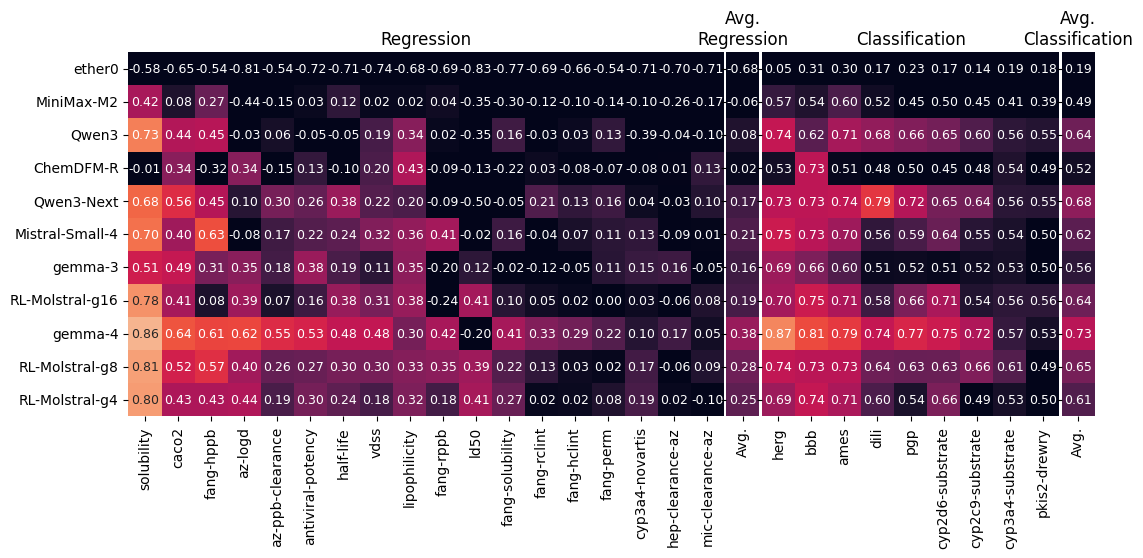

In [15]:
n_tot_cols = table.Task.nunique() + 2
n_rows = table.Model.nunique()

reg_ratio = table[table.objectives == "regression"].Task.nunique() / n_tot_cols
cls_ratio = table[table.objectives == "classification"].Task.nunique() / n_tot_cols

fig, axes = plt.subplots(
    1,
    4,
    figsize = (0.43*n_tot_cols,0.43 * n_rows),
    sharey=True,
    gridspec_kw = {
        "width_ratios":[reg_ratio, 1/n_tot_cols, cls_ratio,  1/n_tot_cols],
        "wspace":0.01,
    }
)

plot_heatmap(table, [axes[0],axes[1]], "Regression", "regression", annot_size=9)
plot_heatmap(table, [axes[2],axes[3]], "Classification", "classification", vmin = 0.5, vmax=1, annot_size= 9)

for ax in axes[1:]:
    ax.set_ylabel("")

fig.savefig(f"{FIG_PATH}/molecular_proppred_heatmap.pdf", bbox_inches="tight")

# Radar Charts

In [16]:
REMOVE_MODELS = [
    "ether0",  "R1-Llama", "R1-Qwen", "MiniMax-M2", "Qwen3"
]

In [17]:
table

,Task,Model,objectives,Metric
0,herg,ChemDFM-R,classification,0.525922
1,herg,MiniMax-M2,classification,0.571552
2,herg,Mistral-Small-4,classification,0.751529
3,herg,Qwen3,classification,0.740410
4,herg,Qwen3-Next,classification,0.731318
...,...,...,...,...
292,mic-clearance-az,RL-Molstral-g4,regression,-0.101974
293,mic-clearance-az,RL-Molstral-g8,regression,0.089772
294,mic-clearance-az,ether0,regression,-0.708261
295,mic-clearance-az,gemma-3,regression,-0.051280


/tmp/ipykernel_3047192/127861576.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')


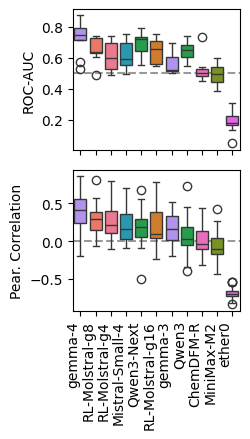

In [91]:
# Order models by average performance for each objective
x_order = table.groupby("Model")["Metric"].mean().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2,1,figsize=(2.6,4.5), sharex=True)
axes[0].axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, alpha=0.4, label='Random guess')
axes[1].axhline(y=0.0, color='black', linestyle='--', linewidth=1.5, alpha=0.4, label='Random guess')
sns.boxplot(table[table.objectives == "classification"], x="Model", y="Metric", hue="Model", palette = CMAP_MODELS, ax = axes[0], legend=False, order=x_order)
# Add dashed line for random guess (ROC-AUC = 0.5)

# axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=60, ha='right')
sns.boxplot(table[table.objectives == "regression"], x="Model", y="Metric", hue="Model", palette = CMAP_MODELS, ax = axes[1], legend=False, order=x_order)
# Add dashed line for random guess (Pearson Correlation = 0.0)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, ha='right')
axes[1].set_xlabel("")

axes[0].set_ylabel("ROC-AUC")
axes[1].set_ylabel("Pear. Correlation")


fig.tight_layout()
fig.savefig(f"{FIG_PATH}/molecular_proppred_box.pdf", bbox_inches="tight")

In [28]:
baseline

Series([], Name: Metric, dtype: float64)

In [35]:
# Calculate Delta as improvement over MistralSmall4
baseline = table[table.Model == "Mistral-Small-4"].set_index(["Task"])["Metric"]
table[r"$\Delta$"] = table.apply(
    lambda row: row["Metric"] - baseline.get((row["Task"]), np.nan),
    axis=1
)

/tmp/ipykernel_3047192/1370664171.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
/tmp/ipykernel_3047192/1370664171.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=table[table.Model.apply(lambda x: "Molstral" in x)], x="Model", y=r"$\Delta$", palette=CMAP_MODELS, ax=ax)
/tmp/ipykernel_3047192/1370664171.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
/tmp/ipykernel_3047192/1370664171.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


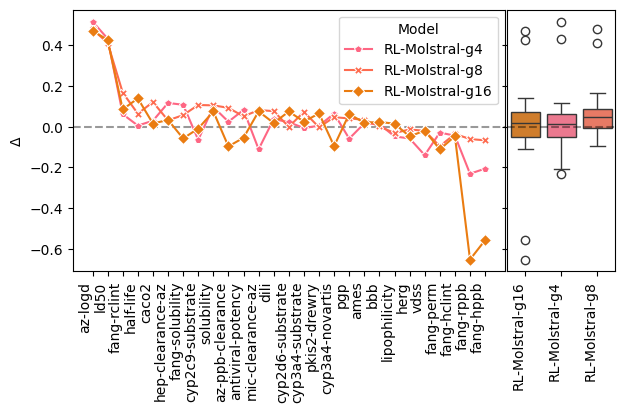

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4), gridspec_kw={"width_ratios": [0.8, 0.2], "wspace": 0.01}, sharey=True)



ax = axes[0]
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.4)
sns.lineplot(table[table.Model.apply(lambda x: "Molstral" in x)].sort_values(r"\Delta")[::-1], x="Task", y=r"$\Delta$", hue="Model", palette=CMAP_MODELS, style="Model", markers=MARKER_MODELS, dashes=False, ax=ax)
ax.set_xlabel("")
ax.set_ylabel(r"$\Delta$")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

ax = axes[1]
sns.boxplot(data=table[table.Model.apply(lambda x: "Molstral" in x)], x="Model", y=r"$\Delta$", palette=CMAP_MODELS, ax=ax)
ax.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.4)
ax.set_xlabel(r"")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

fig.tight_layout()
fig.savefig(f"{FIG_PATH}/molecular_proppred_delta.pdf", bbox_inches="tight")

In [50]:
(table[table.Model.apply(lambda x: "Molstral" in x)].groupby(["Model", "Task",])[r"$\Delta$"].mean()>0).reset_index().groupby("Model")[r"$\Delta$"].mean()

Model
RL-Molstral-g16    0.592593
RL-Molstral-g4     0.592593
RL-Molstral-g8     0.666667
Name: $\Delta$, dtype: float64

# Comprehensive Metrics

## Classification

In [92]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

df = full_df[full_df.objectives == "classification"]

def get_yagg(values):
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.round(np.mean(values) + 1e-8 * values[0]).clip(0,1)

df["y_agg"] = df.groupby(["Model", "Task", "prompt_id"]).y.transform(get_yagg)



# Compute Accuracy

metric_df = df[df.validity == 1].groupby(
    ["Model", "Task"]
)[["gt", "y_agg"]].apply(
    lambda x: pd.Series(
        {
            "ROC-AUC": roc_auc_score(x["gt"], x["y_agg"]),
            "Accuracy": accuracy_score(x["gt"], x["y_agg"].round()),
            "Avg. Precision": average_precision_score(x["gt"], x["y_agg"]),
        }
    )
)
coverage = df.groupby(["Model", "Task"]).validity.mean()

for col in metric_df.columns:
    metric_df[col] = metric_df[col] * coverage

metric_df


ROC-AUC  Accuracy  Avg. Precision
Model     Task                                                
ChemDFM-R ames              0.509001  0.480687        0.535821
          bbb               0.733879  0.718154        0.845655
          cyp2c9-substrate  0.484543  0.762617        0.174779
          cyp2d6-substrate  0.451404  0.620561        0.289174
          cyp3a4-substrate  0.542647  0.525234        0.551375
...                              ...       ...             ...
gemma-4   cyp3a4-substrate  0.571254  0.588785        0.561662
          dili              0.740278  0.736842        0.707082
          herg              0.873583  0.914286        0.905808
          pgp               0.768015  0.788718        0.729646
          pkis2-drewry      0.528952  0.216981        0.166124

[99 rows x 3 columns]

In [93]:
from notebooks.utils import PandasTableFormatter
LATEX_PATH = "MolGenDocking-latex/tables/results"


formatter = PandasTableFormatter(
        n_decimals = 2, # Number of decimals to keep in the table
        aggregation_methods=["mean"], # Aggregation functions to apply to the data
        main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
        hide_agg_labels=True, # Hide the aggregation column names in the latex
        global_agg=False, # Whether to compute global aggregation across all columns (True)
    )

latexs = {}
header = ""
footer = ""

for metric in metric_df.columns:
    df_m = metric_df.reset_index()
    df_m = df_m[df_m.Model != "ether0"]
    df_m["Task"] = df_m["Task"].apply(lambda x: x.replace("-substrate", ""))

    style = formatter.style(
        df_m, # Dataframe to format
        rows= ["Model"], # Rows
        cols=["Task"], # Columns
        values= metric, # Values
        highlight_fn= np.nanmax, # Function to use to highlight the values, here the maximum values will be highlighted
        props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex",], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
        remove_col_names=True,
    )
    latex = formatter.latex(
        style, multicol_align="c||", hrules=True, cols_sep=1
    )
    latexs[metric] = latex.split("\n")[3:-3]
    latexs[metric] = [
        r"\midrule",
        r"\midrule",
        r" & \multicolumn{" + str(df_m.Task.nunique())  + r"}{c}{" + metric + r"} \\",
        r"\midrule",
    ] + latexs[metric]

    header = latex.split("\n")[:3]
    footer = latex.split("\n")[-3:]

In [94]:

final_latex = "\n".join(
    header + sum(
        latexs.values(),[]
    ) + footer
)

with open(f"{LATEX_PATH}/comprehensive_cls_res.tex", "w") as f:
    f.write(final_latex)

print(final_latex)

\begin{tabular}{c||ccccccccc}
\toprule
 & ames & bbb & cyp2c9 & cyp2d6 & cyp3a4 & dili & herg & pgp & pkis2-drewry \\
\midrule
\midrule
 & \multicolumn{9}{c}{ROC-AUC} \\
\midrule
\midrule
ChemDFM-R & 0.51 & 0.73 & 0.48 & 0.45 & 0.54 & 0.48 & 0.53 & 0.50 & 0.49 \\
MiniMax-M2 & 0.60 & 0.54 & 0.45 & 0.50 & 0.41 & 0.52 & 0.57 & 0.45 & 0.39 \\
Mistral-Small-4 & 0.70 & 0.73 & 0.55 & 0.64 & 0.54 & 0.56 & \underline{0.75} & 0.59 & 0.50 \\
Qwen3 & 0.71 & 0.62 & 0.60 & 0.65 & 0.56 & 0.68 & 0.74 & 0.66 & 0.55 \\
Qwen3-Next & \underline{0.74} & 0.73 & 0.64 & 0.65 & 0.56 & \textbf{\underline{0.79}} & 0.73 & \underline{0.72} & \underline{0.55} \\
RL-Molstral-g16 & 0.71 & \underline{0.75} & 0.54 & \underline{0.71} & 0.56 & 0.58 & 0.70 & 0.66 & \textbf{\underline{0.56}} \\
RL-Molstral-g4 & 0.71 & 0.74 & 0.49 & 0.66 & 0.53 & 0.60 & 0.69 & 0.54 & 0.50 \\
RL-Molstral-g8 & 0.73 & 0.73 & \underline{0.66} & 0.63 & \textbf{\underline{0.61}} & 0.64 & 0.74 & 0.63 & 0.49 \\
gemma-3 & 0.60 & 0.66 & 0.52 & 0.51 &

# Regression

In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr

df = full_df[full_df.objectives == "regression"]

def get_yagg_regression(values):
    """
    Aggregate y values for regression.
    If no valid float values, return NaN.
    """
    values = [v for v in values if not np.isnan(v)]
    if len(values) == 0:
        return np.nan
    return np.mean(values)

# Add y_agg for each (Model, prompt_id)
df["y_agg"] = df.groupby(["Model", "prompt_id"]).y.transform(get_yagg_regression)

def compute_regression_metrics(x):
    """
    Compute regression metrics for valid predictions.
    If no valid float values for y_agg, use the mean y value instead.
    """
    # Filter for valid predictions
    valid_mask = x["validity"] == 1
    valid_data = x[valid_mask]

    if len(valid_data) == 0:
        return pd.Series({
            "MAE": np.nan,
            "MSE": np.nan,
            "R2": np.nan,
            "PearsonR": np.nan,
            "SpearmanR": np.nan,
        })

    gt_values = valid_data["gt"].values
    y_values = valid_data["y_agg"].values

    # If all y_values are NaN, use mean y value across all completions instead
    if np.isnan(y_values).all():
        y_values = valid_data["y"].values
        y_values = y_values[~np.isnan(y_values)]
        if len(y_values) == 0:
            return pd.Series({
                "PearsonR": np.nan,
                "SpearmanR": np.nan,
            })
        # Use mean y value for all predictions
        y_values = np.full(len(gt_values), np.mean(y_values))
    else:
        nanmean = np.nanmean(y_values)

        invalid_mask = np.isnan(y_values) * nanmean
        y_values = y_values + invalid_mask


        if len(y_values) == 0:
            return pd.Series({
                "PearsonR": np.nan,
                "SpearmanR": np.nan,
            })

    pearson_r, _ = pearsonr(gt_values, y_values)
    spearman_r, _ = spearmanr(gt_values, y_values)
    return pd.Series({
        "PearsonR": pearson_r,
        "SpearmanR": spearman_r,
    })

metric_df_reg = df[df.Model != "ether0"].groupby(["Model", "Task"]).apply(compute_regression_metrics)

metric_df_reg

PearsonR  SpearmanR
Model     Task                                  
ChemDFM-R antiviral-potency  0.188710   0.189247
          az-logd            0.439873   0.483422
          az-ppb-clearance  -0.043722  -0.109517
          caco2              0.436368   0.380056
          cyp3a4-novartis    0.002140   0.127667
...                               ...        ...
gemma-4   ld50              -0.197243  -0.190179
          lipophilicity      0.299069   0.261782
          mic-clearance-az   0.047566   0.083251
          solubility         0.856280   0.884013
          vdss               0.476809   0.512315

[180 rows x 2 columns]

In [96]:
metric_df_reg.reset_index().Task.nunique()

18

In [100]:
from notebooks.utils import PandasTableFormatter
LATEX_PATH = "MolGenDocking-latex/tables/results"

formatter = PandasTableFormatter(
        n_decimals = 2, # Number of decimals to keep in the table
        aggregation_methods=["mean"], # Aggregation functions to apply to the data
        main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
        hide_agg_labels=True, # Hide the aggregation column names in the latex
        global_agg=False, # Whether to compute global aggregation across all columns (True)
    )

latexs_reg = {}
header_reg = ""
footer_reg = ""

for metric in metric_df_reg.columns:
    df_m = metric_df_reg.reset_index()
    df_m = df_m[df_m.Task.isin(df_m.Task.unique()[:9])]
    df_m = df_m[~df_m.Model.str.contains("g4|g8")]

    style = formatter.style(
        df_m, # Dataframe to format
        rows= ["Model"], # Rows
        cols=["Task"], # Columns
        values= metric, # Values
        highlight_fn= np.nanmax if "R" in metric else np.nanmin, # Function to use to highlight the values, here the maximum values will be highlighted
        props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex",], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
        remove_col_names=True,
    )
    latex = formatter.latex(
        style, multicol_align="c||", hrules=True, cols_sep=1
    )
    latexs_reg[metric] = latex.split("\n")[3:-3]
    latexs_reg[metric] = [
        r"\midrule",
        r"\midrule",
        r" & \multicolumn{" + str(df_m.Task.nunique())  + r"}{c}{" + metric + r"} \\",
        r"\midrule",
    ] + latexs_reg[metric]

    header_reg = latex.split("\n")[:3]
    footer_reg = latex.split("\n")[-3:]


final_latex_reg = "\n".join(
    header_reg + sum(
        latexs_reg.values(),[]
    ) + footer_reg
)

with open(f"{LATEX_PATH}/comprehensive_reg_res0.tex", "w") as f:
    f.write(final_latex_reg)

print(final_latex_reg)

\begin{tabular}{c||ccccccccc}
\toprule
 & antiviral-potency & az-logd & az-ppb-clearance & caco2 & cyp3a4-novartis & fang-hclint & fang-hppb & fang-perm & fang-rclint \\
\midrule
\midrule
 & \multicolumn{9}{c}{PearsonR} \\
\midrule
\midrule
ChemDFM-R & 0.19 & \underline{0.44} & -0.04 & 0.44 & 0.00 & -0.04 & -0.27 & -0.02 & 0.07 \\
MiniMax-M2 & 0.37 & 0.09 & 0.07 & 0.39 & \underline{0.22} & 0.13 & 0.57 & 0.18 & 0.08 \\
Mistral-Small-4 & 0.36 & -0.00 & 0.27 & 0.51 & \textbf{\underline{0.28}} & 0.13 & \textbf{\underline{0.70}} & 0.16 & 0.04 \\
Qwen3 & 0.33 & -0.01 & 0.08 & 0.44 & 0.04 & 0.05 & 0.46 & 0.16 & 0.00 \\
Qwen3-Next & \underline{0.40} & 0.43 & \underline{0.34} & \textbf{\underline{0.66}} & 0.13 & \underline{0.14} & 0.53 & \underline{0.19} & \underline{0.23} \\
RL-Molstral-g16 & 0.16 & 0.39 & 0.07 & 0.41 & 0.03 & 0.02 & 0.08 & 0.00 & 0.05 \\
gemma-3 & 0.38 & 0.35 & 0.18 & 0.49 & 0.15 & -0.05 & 0.31 & 0.11 & -0.12 \\
gemma-4 & \textbf{\underline{0.53}} & \textbf{\underline{0.62}} 

In [101]:
from notebooks.utils import PandasTableFormatter
LATEX_PATH = "MolGenDocking-latex/tables/results"

formatter = PandasTableFormatter(
        n_decimals = 2, # Number of decimals to keep in the table
        aggregation_methods=["mean"], # Aggregation functions to apply to the data
        main_subset=0, # Subset of values to bold, here the first column will be bolded corresponding to the mean values, if [0,1] the first two columns will be bolded (independently)
        hide_agg_labels=True, # Hide the aggregation column names in the latex
        global_agg=False, # Whether to compute global aggregation across all columns (True)
    )

latexs_reg = {}
header_reg = ""
footer_reg = ""

for metric in metric_df_reg.columns:
    df_m = metric_df_reg.reset_index()
    df_m = df_m[df_m.Task.isin(df_m.Task.unique()[9:])]

    df_m = df_m[~df_m.Model.str.contains("g4|g8")]
    style = formatter.style(
        df_m, # Dataframe to format
        rows= ["Model"], # Rows
        cols=["Task"], # Columns
        values= metric, # Values
        highlight_fn= np.nanmax if "R" in metric else np.nanmin, # Function to use to highlight the values, here the maximum values will be highlighted
        props=["textbf:--rwrap--latex; underline:--rwrap--latex", "underline:--rwrap--latex",], # Properties to apply to the highlighted values, here the maximum values will be underlined and bolded, the second maximum values will be bolded
        remove_col_names=True,
    )
    latex = formatter.latex(
        style, multicol_align="c||", hrules=True, cols_sep=1
    )
    latexs_reg[metric] = latex.split("\n")[3:-3]
    latexs_reg[metric] = [
        r"\midrule",
        r"\midrule",
        r" & \multicolumn{" + str(df_m.Task.nunique())  + r"}{c}{" + metric + r"} \\",
        r"\midrule",
    ] + latexs_reg[metric]

    header_reg = latex.split("\n")[:3]
    footer_reg = latex.split("\n")[-3:]


final_latex_reg = "\n".join(
    header_reg + sum(
        latexs_reg.values(),[]
    ) + footer_reg
)

with open(f"{LATEX_PATH}/comprehensive_reg_res1.tex", "w") as f:
    f.write(final_latex_reg)

print(final_latex_reg)

\begin{tabular}{c||ccccccccc}
\toprule
 & fang-rppb & fang-solubility & half-life & hep-clearance-az & ld50 & lipophilicity & mic-clearance-az & solubility & vdss \\
\midrule
\midrule
 & \multicolumn{9}{c}{PearsonR} \\
\midrule
\midrule
ChemDFM-R & -0.03 & -0.15 & -0.04 & 0.06 & -0.03 & \textbf{\underline{0.52}} & \textbf{\underline{0.20}} & 0.08 & 0.31 \\
MiniMax-M2 & \underline{0.42} & 0.16 & \textbf{\underline{0.53}} & -0.03 & -0.20 & 0.35 & 0.10 & 0.82 & \underline{0.44} \\
Mistral-Small-4 & \textbf{\underline{0.46}} & \underline{0.31} & 0.40 & 0.04 & 0.10 & \underline{0.43} & \underline{0.16} & \underline{0.83} & 0.43 \\
Qwen3 & 0.04 & 0.24 & 0.17 & \underline{0.17} & -0.33 & 0.36 & 0.08 & 0.76 & 0.24 \\
Qwen3-Next & -0.02 & 0.29 & \underline{0.49} & -0.01 & -0.49 & 0.39 & 0.11 & 0.79 & 0.28 \\
RL-Molstral-g16 & -0.24 & 0.10 & 0.38 & -0.06 & \textbf{\underline{0.41}} & 0.38 & 0.08 & 0.78 & 0.31 \\
gemma-3 & -0.20 & -0.02 & 0.19 & 0.16 & \underline{0.12} & 0.35 & -0.05 & 0.51 & 0.1